# Baseball Data Analysis

- Use **NumPy** to load and explore baseball data, and **Matplotlib** to visualize time series on a single chart and across multiple sub-charts.
- Data source: https://www.kaggle.com/datasets/open-source-sports/baseball-databank?select=Salaries.csv
- I used Gemini to create the specific questions at present to answer based on the current baseball databank.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Q1. Player lookup by year
- Use NumPy boolean masks to find a specific player's full name and home run total for a given year.
- Load the player master list and batting records, filter by player ID and year, then print the matching name and home run count.

In [34]:
master = np.genfromtxt('Data/Master.csv', delimiter=',', dtype=None, names=True, encoding='utf-8')
batting = np.genfromtxt('Data/Batting.csv', delimiter=',', dtype=None, names=True, encoding='utf-8')
search_year = int(input("Enter the year: "))
search_hr = int(input("Enter the number of home runs: "))
year_mask = batting['yearID'] == search_year
hr_mask = batting['HR'] == search_hr
matching_rows = batting[year_mask & hr_mask]
if matching_rows.size > 0:
    print(f"\nPlayers who hit {search_hr} home runs in {search_year}:\n")
    for row in matching_rows:
        player_id = row['playerID']
        player_match = master[master['playerID'] == player_id]
        if player_match.size > 0:
            player_row = player_match[0]
            first_name = player_row['nameFirst']
            last_name = player_row['nameLast']
            if isinstance(first_name, bytes):
                first_name = first_name.decode('utf-8')
            if isinstance(last_name, bytes):
                last_name = last_name.decode('utf-8')
            print(f"- {first_name} {last_name}")
else:
    print(f"No players with {search_hr} home runs in {search_year}.")


Players who hit 28 home runs in 2003:

- Nomar Garciaparra
- Richard Hidalgo
- Geoff Jenkins
- Trot Nixon
- Jay Payton
- Scott Rolen
- Jose Valentin


## Q2. Barry Bonds home run trajectory
- Load Barry Bonds's yearly home run totals from `Batting.csv` and visualize his power-hitting career.
- Filter `Batting.csv` for Barry Bonds, then convert the year and home-run columns into NumPy arrays for plotting.

In [33]:
batting = np.genfromtxt('Data/Batting.csv', delimiter=',', dtype=None, names=True, encoding='utf-8')
bonds_rows = batting[batting['playerID'] == 'bondsba01']
bonds_years = bonds_rows['yearID'].astype(float)
bonds_home_runs = bonds_rows['HR'].astype(float)
print('Barry Bonds — Home Runs per Year')
print('Years:', bonds_years)
print('HR:', bonds_home_runs)

Barry Bonds — Home Runs per Year
Years: [1986. 1987. 1988. 1989. 1990. 1991. 1992. 1993. 1994. 1995. 1996. 1997.
 1998. 1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007.]
HR: [16. 25. 24. 19. 33. 25. 34. 46. 37. 33. 42. 40. 37. 34. 49. 73. 46. 45.
 45.  5. 26. 28.]


### Plot Graph of Barry Bonds home runs by year
- Plot Barry Bonds's career home runs as a line chart over time.

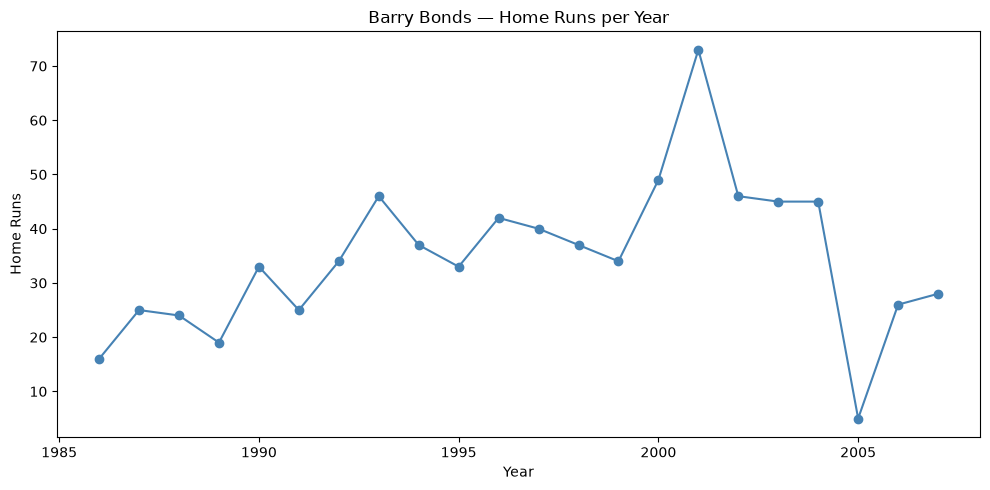

In [30]:
figure, axis = plt.subplots(figsize=(10, 5))
axis.plot(bonds_years, bonds_home_runs, color='steelblue', marker='o')
axis.set_title('Barry Bonds — Home Runs per Year')
axis.set_xlabel('Year')
axis.set_ylabel('Home Runs')
plt.tight_layout()
plt.show()

### Plot Graph of Barry Bonds home runs by decade
- Split Barry Bonds's home run data into separate sub-charts for each decade.

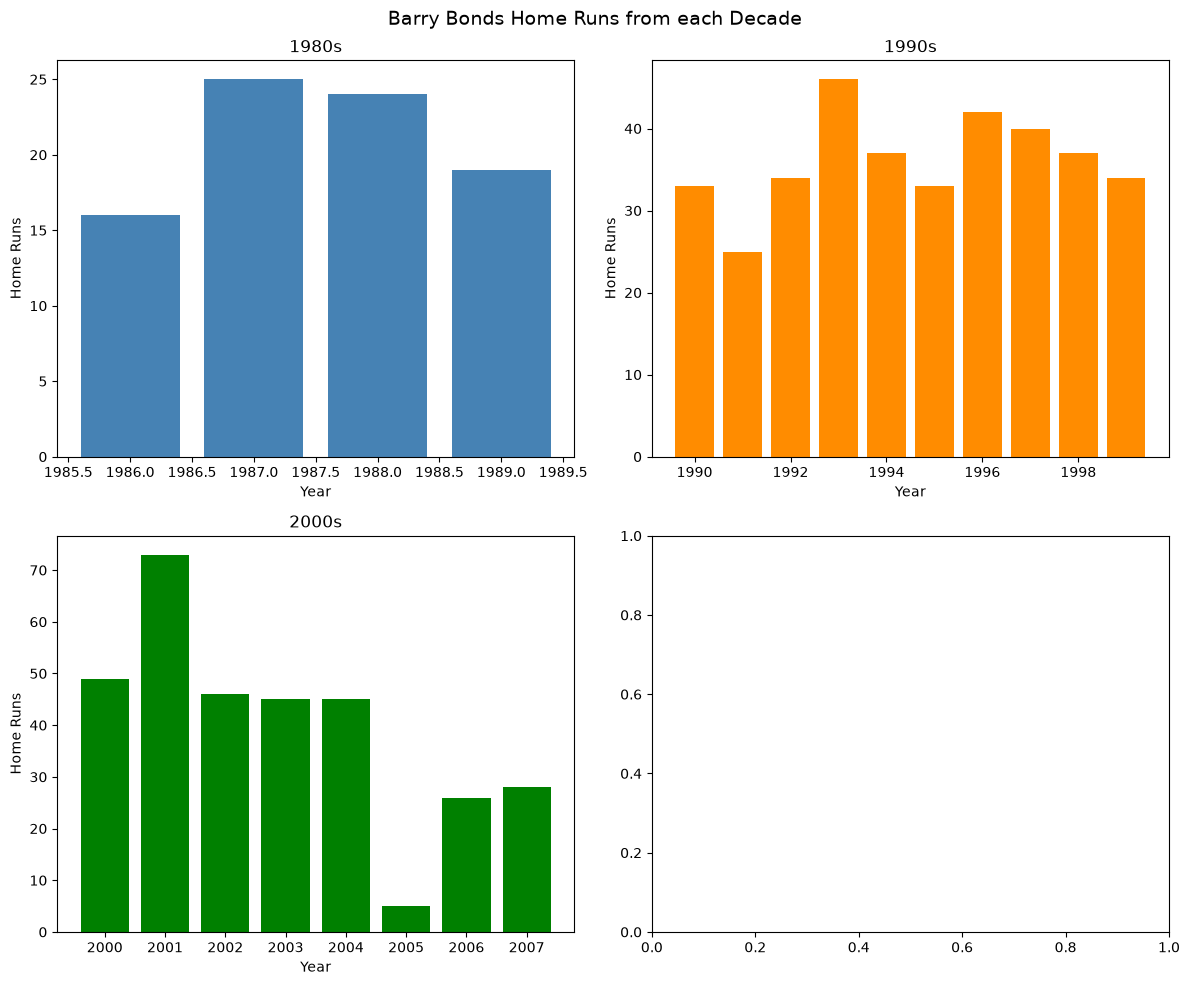

In [29]:
figure, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

decade_list = [1980, 1990, 2000]
color_list = ['steelblue', 'darkorange', 'green']

for index, decade in enumerate(decade_list):
    in_decade = (bonds_years >= decade) & (bonds_years < decade + 10)
    decade_years = bonds_years[in_decade]
    decade_home_runs = bonds_home_runs[in_decade]
    axes[index].bar(decade_years, decade_home_runs, color=color_list[index])
    axes[index].set_title(f'{decade}s')
    axes[index].set_xlabel('Year')
    axes[index].set_ylabel('Home Runs')

figure.suptitle('Barry Bonds Home Runs from each Decade', fontsize=14)
plt.tight_layout()
plt.show()

## Q3. Cy Young ERA trend
- Load Cy Young's yearly pitching data from `Pitching.csv` and visualize his career ERA trend.
- Filter `Pitching.csv` for Cy Young, remove missing ERA values, and convert year and ERA into NumPy arrays for plotting.

In [28]:
pitching = np.genfromtxt('Data/Pitching.csv', delimiter=',', dtype=None, names=True, encoding='utf-8')

cy_rows = pitching[pitching['playerID'] == 'youngcy01']

cy_years = cy_rows['yearID'].astype(float)
cy_era = cy_rows['ERA'].astype(float)

not_missing = ~np.isnan(cy_era)
clean_years = cy_years[not_missing]
clean_era = cy_era[not_missing]

print('Cy Young ERA by Year')
print('Years:', clean_years)
print('ERA:', clean_era)

Cy Young ERA by Year
Years: [1890. 1891. 1892. 1893. 1894. 1895. 1896. 1897. 1898. 1899. 1900. 1901.
 1902. 1903. 1904. 1905. 1906. 1907. 1908. 1909. 1910. 1911. 1911.]
ERA: [3.47 2.85 1.93 3.36 3.94 3.26 3.24 3.8  2.53 2.58 3.   1.62 2.15 2.08
 1.97 1.82 3.19 1.99 1.26 2.26 2.53 3.71 3.88]


### Plot Graph of Cy Young ERA by year
- Plot Cy Young's career ERA as a line chart over time.

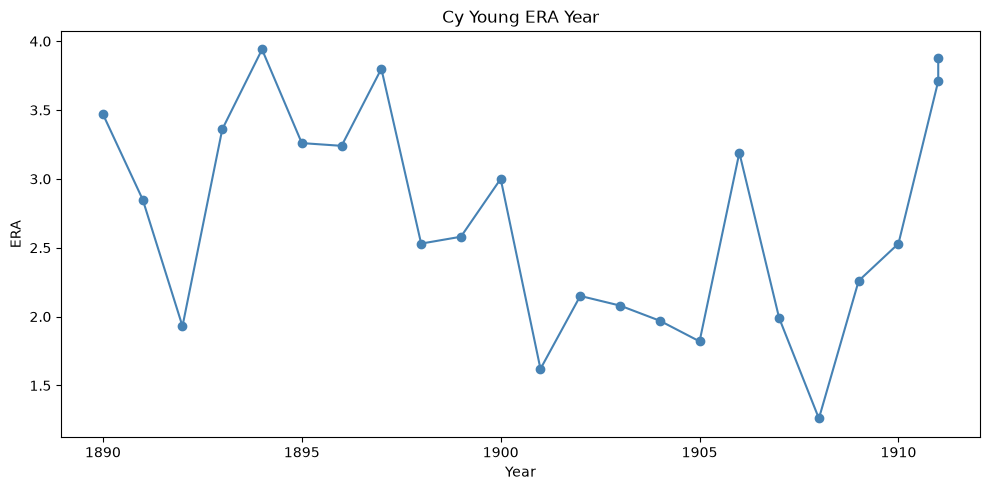

In [27]:
figure, axis = plt.subplots(figsize=(10, 5))
axis.plot(clean_years, clean_era, color='steelblue', marker='o')
axis.set_title('Cy Young ERA Year')
axis.set_xlabel('Year')
axis.set_ylabel('ERA')
plt.tight_layout()
plt.show()

### Plot Graph of Cy Young ERA by team
- Split Cy Young's ERA data into separate sub-charts for each team he played for.

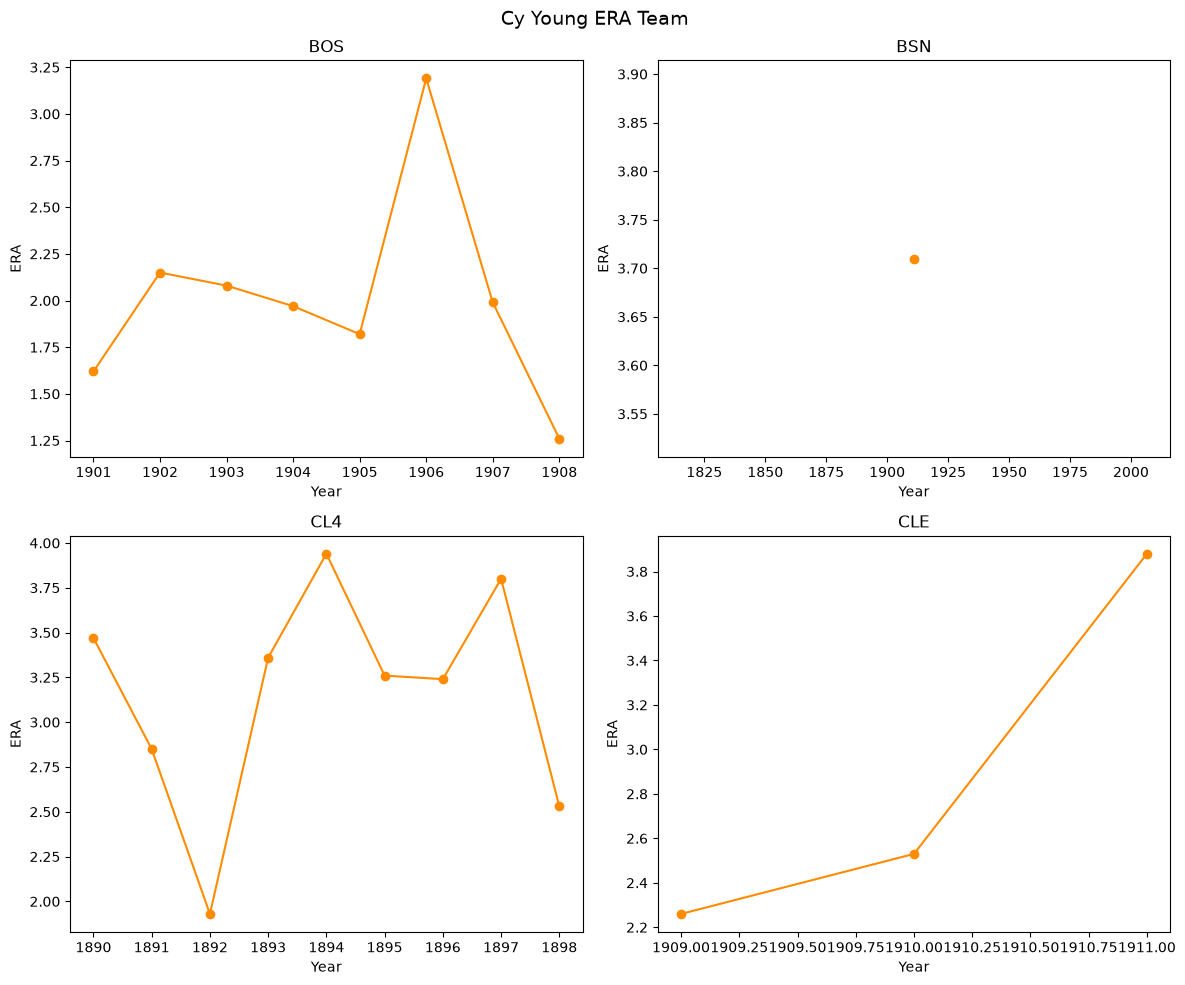

In [ ]:
figure, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for index, team in enumerate(selected_teams):
    team_mask = cy_rows['teamID'][not_missing] == team
    team_years = clean_years[team_mask]
    team_era = clean_era[team_mask]
    sort_index = np.argsort(team_years)
    team_years = team_years[sort_index]
    team_era = team_era[sort_index]
    
    axes[index].plot(team_years, team_era, color='darkorange', marker='o')
    axes[index].set_title(team)
    axes[index].set_xlabel('Year')
    axes[index].set_ylabel('ERA')

figure.suptitle('Cy Young ERA Team', fontsize=14)
plt.tight_layout()
plt.show()

## Q4. Bonds vs. Rodriguez home run matrix
- Compare Barry Bonds and Alex Rodriguez by building a NumPy matrix of home runs by decade and visualizing the matchup.
- Filter `Batting.csv` for Barry Bonds and Alex Rodriguez, then build a 2-row matrix of total home runs by decade.

In [25]:
batting = np.genfromtxt('Data/Batting.csv', delimiter=',', dtype=None, names=True, encoding='utf-8')

player_ids = ['bondsba01', 'rodrial01']
player_names = ['Barry Bonds', 'Alex Rodriguez']
decade_list = [1990, 2000, 2010]

home_run_matrix = []

for player_id in player_ids:
    player_rows = batting[batting['playerID'] == player_id]
    player_years = player_rows['yearID'].astype(float)
    player_home_runs = player_rows['HR'].astype(float)
    
    decade_totals = []
    for decade in decade_list:
        in_decade = (player_years >= decade) & (player_years < decade + 10)
        total_home_runs = np.sum(player_home_runs[in_decade])
        decade_totals.append(total_home_runs)
    home_run_matrix.append(decade_totals)

home_run_matrix = np.array(home_run_matrix)

print('Home runs by decade (rows=Bonds & Rodriguez, cols=1990s-2010s):')
print(home_run_matrix)

Home runs by decade (rows=Bonds & Rodriguez, cols=1990s-2010s):
[[361. 317.   0.]
 [148. 435. 104.]]


### Plot Graph of Bonds vs. Rodriguez home run matrix
- Display the 2×N home-run matrix as a grouped bar chart on a single graph.

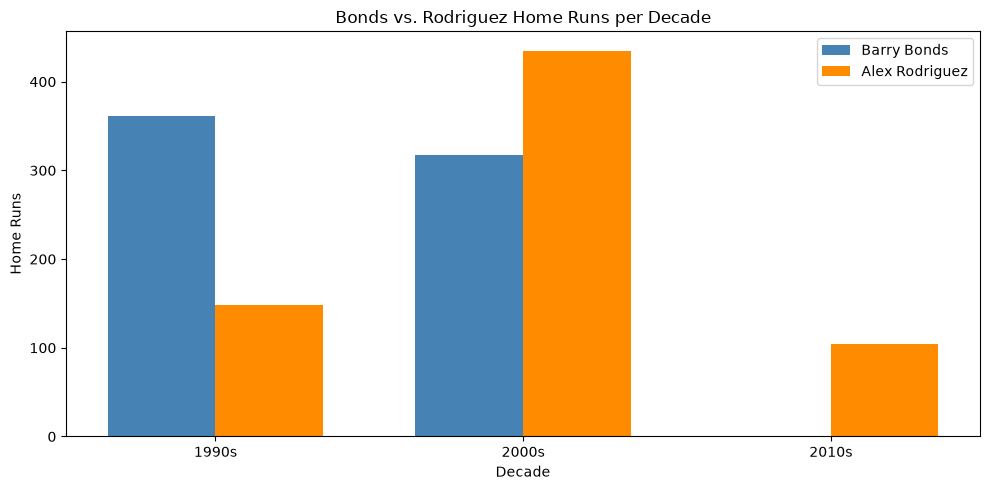

In [24]:
figure, axis = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(decade_list))
bar_width = 0.35

axis.bar(x_positions - bar_width/2, home_run_matrix[0], bar_width, label=player_names[0], color='steelblue')
axis.bar(x_positions + bar_width/2, home_run_matrix[1], bar_width, label=player_names[1], color='darkorange')

axis.set_title('Bonds vs. Rodriguez Home Runs per Decade')
axis.set_xlabel('Decade')
axis.set_ylabel('Home Runs')
axis.set_xticks(x_positions)
axis.set_xticklabels([f'{decade}s' for decade in decade_list])
axis.legend()
plt.tight_layout()
plt.show()

### Plot Graph of Bonds vs. Rodriguez home runs by decade
- split the matrix comparison into separate sub-charts, one decade per chart.

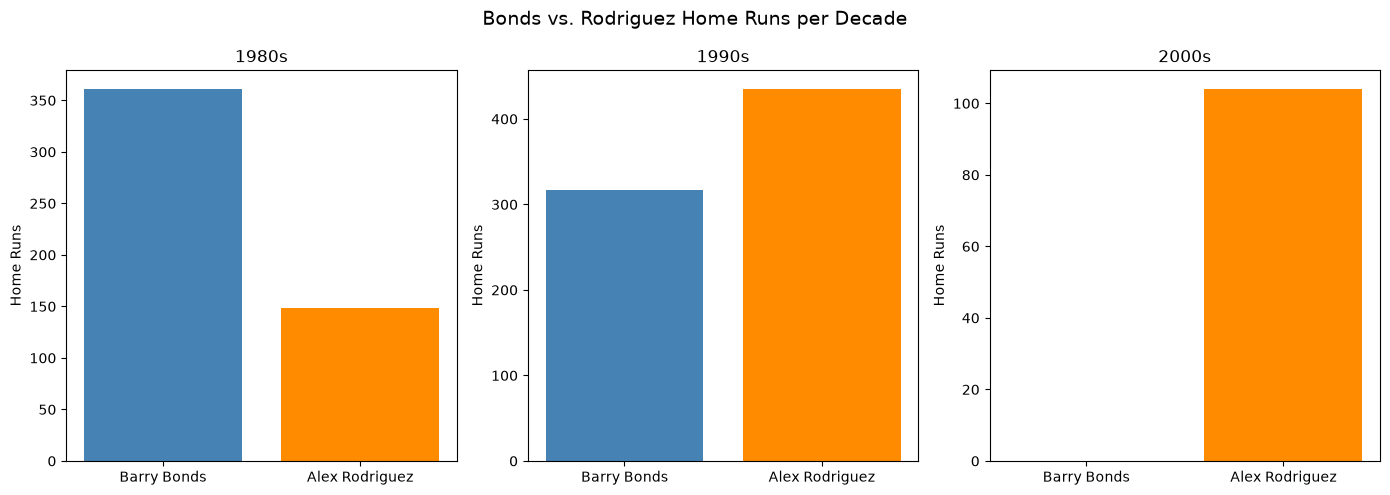

In [37]:
figure, axes = plt.subplots(1, 3, figsize=(14, 5))
axes = axes.ravel()

for index, decade in enumerate(decade_list):
    for row_index, player_name in enumerate(player_names):
        home_runs = home_run_matrix[row_index, index]
        axes[index].bar(player_name, home_runs, color=['steelblue', 'darkorange'][row_index])
    axes[index].set_title(f'{decade}s')
    axes[index].set_ylabel('Home Runs')

figure.suptitle('Bonds vs. Rodriguez Home Runs per Decade', fontsize=14)
plt.tight_layout()
plt.show()